In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ipywidgets.widgets import interact, interactive, fixed
import ipywidgets as widgets
from scipy import fftpack
from PIL import Image
import pims

# Differential Dinamic Microscopy analysis

based on:

Cerbino, Roberto, and Veronique Trappe. "Differential dynamic microscopy: probing wave vector dependent dynamics with a microscope." Physical review letters 100.18 (2008): 188102.

In [2]:
info_dict={'interval': 0.01,
 'filename': '400nm_100dil_water_01umpix_100fps_short.cin',
 'muperpix': 0.1,
 'tracer_radius': 0.2,
 'temperature': 25,
 'operator': 'Marco'}

In [3]:
import pims

@pims.pipeline
def as_grey(frame):
    red = frame[:, :, 0]
    green = frame[:, :, 1]
    blue = frame[:, :, 2]
    return (0.2125 * red + 0.7154 * green + 0.0721 * blue)[:600,:600]

# MFC-01wt-05particle-2.avi
# ThermoMFC_tramp6_25.avi

pims_video=as_grey(pims.Video('MFC-01wt-05particle-2.avi'))

Frame([[122.3136, 122.3136, 122.3136, ..., 120.7406, 120.7406, 120.7406],
       [122.3136, 122.3136, 122.3136, ..., 120.7406, 120.7406, 120.7406],
       [120.3136, 120.3136, 120.3136, ..., 120.7406, 120.7406, 120.7406],
       ...,
       [130.3136, 130.3136, 130.3136, ..., 118.031 , 118.031 , 124.031 ],
       [130.3136, 130.3136, 130.3136, ..., 119.031 , 119.031 , 118.031 ],
       [130.3136, 130.3136, 130.3136, ..., 123.031 , 117.031 , 114.031 ]])
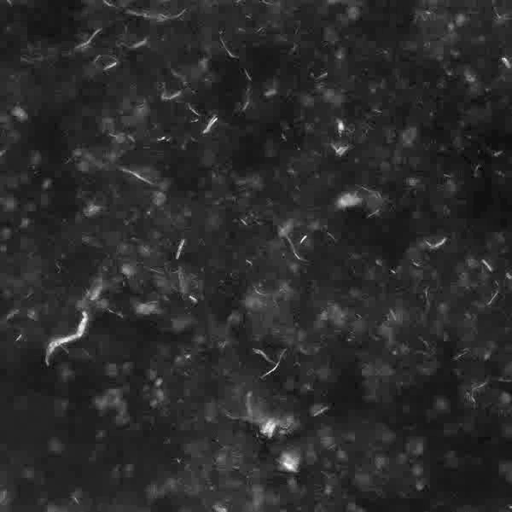

In [4]:
pims_video[1]

In [5]:
import DDM

c:\Users\caggioni.m\Documents\microrheology\microrheology_water_test\DDM.py:50: SyntaxWarning: invalid escape sequence '\D'
  plt.title('(b) image 2 $I(r,t+ \Delta t)$, time: ' + str((framenum+delta)*interval) + ' s')
c:\Users\caggioni.m\Documents\microrheology\microrheology_water_test\DDM.py:57: SyntaxWarning: invalid escape sequence '\D'
  ' s\n $I( q ,t+ \Delta t ) - I(q,t)$')


In [6]:
DDM.browse_images_FFT(pims_video, start_frame=2500, end_frame=3000)

interactive(children=(IntSlider(value=2750, description='framenum', max=3000, min=2500), IntSlider(value=1450,…

In [7]:
pims_video=DDM.calculate_DDM(pims_video,naverage=20,numdt=20,interval=0.01,muperpix=0.1, start_frame=0, end_frame=360)

Text(value='', description='current differential frame realization')

Text(value='0', description='current dt')

In [19]:
def explore_iq_dt(video, interval=1):
    '''
    Expect pims video object
    interval: time between frames in sec
    construct widget to explore DDM results
    '''
    frames=len(video)
    frame_len=min(video.frame_shape[:2])
    
    result=video.result_FFT
    xax=result.columns
    result=result[np.sort(list(xax))]
    deltalistsec=result.index
    iq2=result.values
    xax=result.columns
    
    def view_plot(selectq,deltat):
        clear_output()
        plt.clf()
        plt.figure(figsize=(15,3))
        
        gamma=[]
        aq=[]
        bq=[]
        
        plt.subplot(1,3,1)
        plt.plot(xax,iq2[deltat,:],'o')
        plt.yscale('log')
        plt.xscale('log')
        plt.ylabel('I(q) [a.u.]')
        plt.xlabel('q [um-1]')
        plt.axvline(xax[selectq], color='k', linestyle='--')
        plt.title(r'I(q) fixed $\Delta t$')
        
        
        plt.subplot(1,3,2)
        plt.plot(deltalistsec,iq2[:,selectq],'o')
        plt.xscale('log')
        plt.yscale('log')
        plt.ylabel('g(q,dt) [a.u]')
        plt.xlabel('Delta t [s]')


                 
        result = DDMmod.fit(iq2[1:,selectq], x=deltalistsec[1:], amp=max(iq2[1:,selectq])-min(iq2[1:,selectq]),
                            off=min(iq2[1:,selectq]),
                            tau=np.mean(deltalistsec[1:]));



        
        tau=result.params['tau'].value
        off=result.params['off'].value
        amp=result.params['amp'].value

        plt.plot(deltalistsec[1:], result.best_fit, 'r-')
        plt.axvline(deltat*interval, color='k', linestyle='--')

        plt.subplot(1,3,3)
        plt.plot(deltalistsec,-((iq2[:,selectq]-(off+amp))/amp),'o')
        plt.plot(deltalistsec,np.exp(-deltalistsec/tau))
        plt.axvline(deltat*interval, color='k', linestyle='--')
        plt.xscale('log')
        plt.ylabel('f(q,dt) [a.u.]')
        plt.xlabel('Delta t')
      
        
        
    w=interactive(view_plot, selectq=(1,len(iq2[1,:]-1)),deltat=(1,len(deltalistsec)-1))
    return w

def DDM_func(x, off, amp, tau):
    '''
    single exponential decay function expected for bronian motion of non interacting particles
    '''
    return (off + amp * (1 - np.exp(-x/tau)))

from IPython.display import clear_output
from lmfit import Model
DDMmod = Model(DDM_func)

interactive(children=(IntSlider(value=211, description='selectq', max=422, min=1), IntSlider(value=8, descript…

<Figure size 640x480 with 0 Axes>

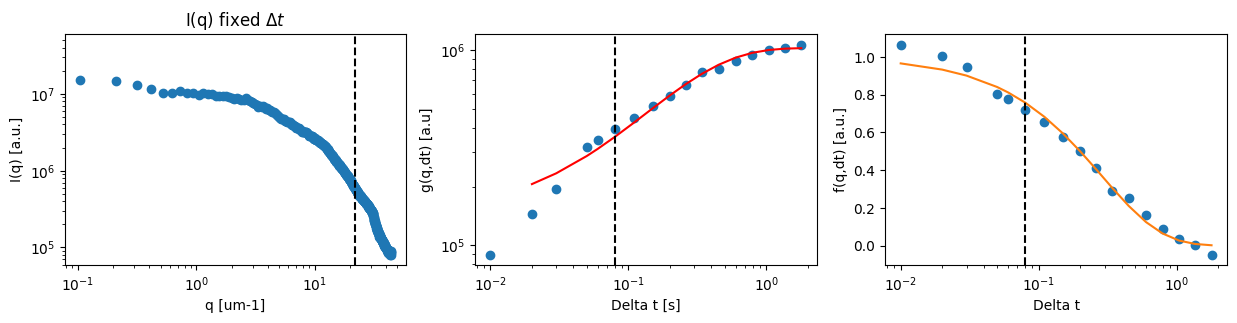

In [21]:
explore_iq_dt(pims_video, interval=0.01)

$$g(q,\tau) = A(q) [1-f(q,\tau)] +B(q)$$

$$f(q,\tau) = e^{-Dq^2 \tau}$$

$$ \tau=\frac{D}{q^2}$$

Text(0, 0.5, 'q')

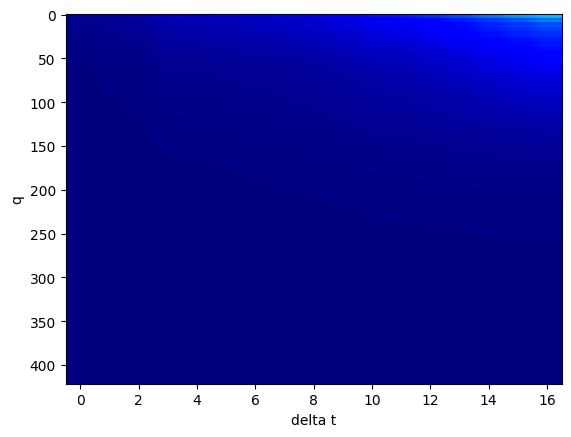

In [22]:
plt.imshow(pims_video.result_FFT.transpose(),cmap='jet',aspect='auto')
plt.xlabel("delta t")
plt.ylabel('q')

0.0010245998208265143


0.0010245998208265143

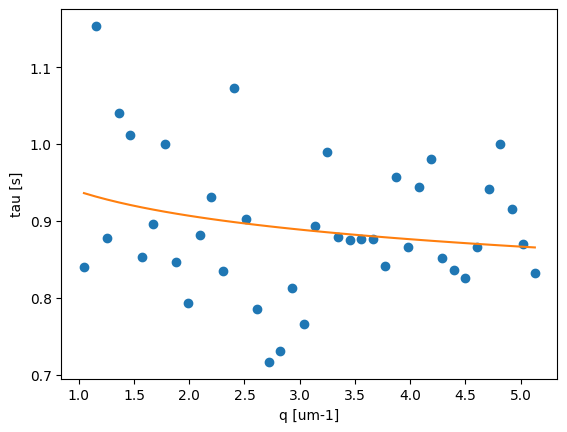

In [23]:
DDM.calculate_viscosity(pims_video,radius=0.2,muperpix=0.1,qmin=10,qmax=50)